# 🧠 Product Price Predictor using Python


In [513]:


from lib.product import Product
from lib.pricing_rule import PricingRule
from lib.delivery_rule import DeliveryRule
from lib.quantity_pricing import QuantityPricing
from lib.attribute import Attribute
from lib.price_calculation_request import PriceCalculationRequest
from lib.pricing_engine import PricingEngine
import json
import re

In [514]:
vendor_product = {
    "product": {"name": "Premium Poster"},
    "pricingRules": [
        # === Paper Type ===
        {"attribute": "paper", "value": "matte", "price": 10},
        {"attribute": "paper", "value": "glossy", "price": 20},
        {"attribute": "paper", "value": "satin", "price": 15},

        # === Size ===
        {"attribute": "size", "value": "A4", "price": 10},
        {"attribute": "size", "value": "A3", "price": 20},
        {"attribute": "size", "value": "A2", "price": 40},
        {"attribute": "size", "value": "A1", "price": 70},

        # === Color Mode ===
        {"attribute": "color_mode", "value": "bw", "price": 0},
        {"attribute": "color_mode", "value": "full_color", "price": 30},

        # === Lamination ===
        {"attribute": "lamination", "value": "none", "price": 0},
        {"attribute": "lamination", "value": "gloss", "price": 25},
        {"attribute": "lamination", "value": "matte", "price": 20},
    ],

    "deliverySlots": [
        {"label": "standard", "price": 30},
        {"label": "express", "price": 60},
        {"label": "same_day", "price": 100},
    ],

    "quantityPricings": [
        {"quantity": 10, "price": 200},
        {"quantity": 25, "price": 400},
        {"quantity": 50, "price": 700},
        {"quantity": 100, "price": 1200},
        {"quantity": 250, "price": 2500},
        {"quantity": 500, "price": 4500},
        {"quantity": 750, "price": 6200},
        {"quantity": 1000, "price": 7800},
    ],

    "vatRate": 12,  # Increased VAT for realism
}

In [515]:



product = Product(
    name=vendor_product["product"]["name"],
    pricing_rules=[PricingRule(r["attribute"], r["value"], r["price"]) for r in vendor_product["pricingRules"]],
    delivery_rules=[DeliveryRule(r["label"], r["price"]) for r in vendor_product["deliverySlots"]],
    quantity_pricings=[QuantityPricing(qp["quantity"], qp["price"]) for qp in vendor_product["quantityPricings"]],
    vat_rate=vendor_product["vatRate"]
)

pricing_engine = PricingEngine(product)
price_request = PriceCalculationRequest(
    product_name="Premium Poster",
    quantity=60,
    selected_attributes=[
        Attribute("paper", "matte"),
        Attribute("size", "A3")
    ],
    delivery_method="express"
)

price_data = pricing_engine.calculate_price(price_request)
print(json.dumps(price_data ,indent=4))

{
    "totalPrice": 1178.9743276601346,
    "status": "complete",
    "breakdown": {
        "basePrice": 756.8819857008486,
        "attributeCost": 242.20223542427152,
        "deliveryCharge": 60,
        "tax": 119.89010653501441
    }
}


In [516]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd 

In [517]:
# === Extract attributes ===
product_name = vendor_product["product"]["name"]
paper = next((p["value"] for p in vendor_product["pricingRules"] if p["attribute"] == "paper"), None)
size = next((p["value"] for p in vendor_product["pricingRules"] if p["attribute"] == "size"), None)

# === Create rows for each quantity tier ===
rows = []
for qp in vendor_product["quantityPricings"]:
    quantity = qp["quantity"]
    base_price = qp["price"]
    attr_price = sum(rule["price"] for rule in vendor_product["pricingRules"])
    total_price = base_price + attr_price
    rows.append({
        "name": product_name,
        "price": total_price,
        "paper": paper,
        "size": size,
        "quantity": quantity
    })

# === Make DataFrame ===
df = pd.DataFrame(data=rows)

df.head()

,name,price,paper,size,quantity
0,Premium Poster,460,matte,A4,10
1,Premium Poster,660,matte,A4,25
2,Premium Poster,960,matte,A4,50
3,Premium Poster,1460,matte,A4,100
4,Premium Poster,2760,matte,A4,250


In [518]:
df['name'] = df['name'].map({
    "Premium Poster" : 1
})
df['paper'] = df['paper'].map({
    "matte" : 1
})

In [519]:
size_map = {
    "A0": (1189, 841),
    "A1": (841, 594),
    "A2": (594, 420),
    "A3": (420, 297),
    "A4": (297, 210),
    "A5": (210, 148),
    "A6": (148, 105),
}

def normalize_size(size_str):
    # Check if standard size
    if size_str in size_map:
        return size_map[size_str]
    # Match custom size like '22mmx23mm' or '100mmx150mm'
    match = re.match(r"(\d+\.?\d*)mm[xX](\d+\.?\d*)mm", size_str)
    if match:
        height, width = match.groups()
        return float(height), float(width)
    # Unknown format
    return None, None
# Apply normalization
df[['height_mm', 'width_mm']] = df['size'].apply(lambda s: pd.Series(normalize_size(s)))
df.drop(columns="size",inplace=True)

print(df)
X_train = df.drop(columns=['price'],inplace=False)
Y_train = df['price'] 

   name  price  paper  quantity  height_mm  width_mm
0     1    460      1        10        297       210
1     1    660      1        25        297       210
2     1    960      1        50        297       210
3     1   1460      1       100        297       210
4     1   2760      1       250        297       210
5     1   4760      1       500        297       210
6     1   6460      1       750        297       210
7     1   8060      1      1000        297       210


In [520]:
scaler = StandardScaler(with_std=True)
X_norm = scaler.fit_transform(X_train)

In [521]:
model = SGDRegressor(max_iter=1000)
model.fit(X_norm,Y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


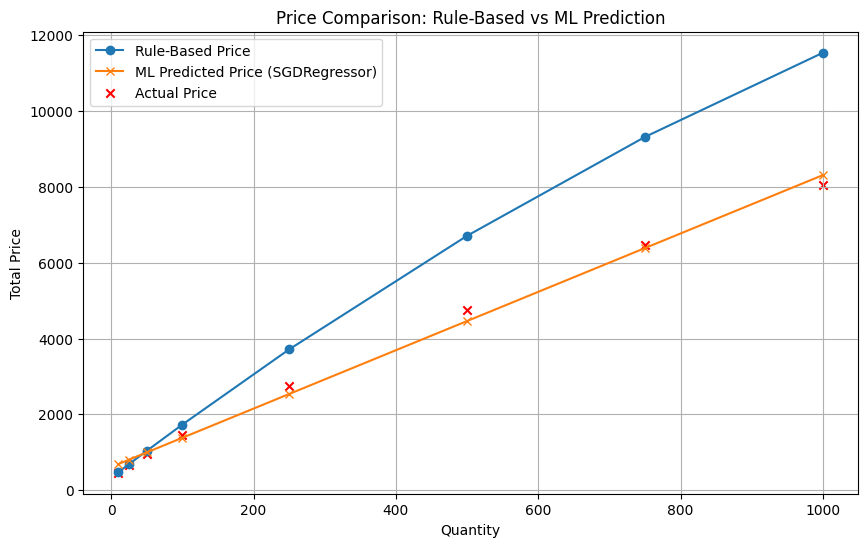

In [522]:
import matplotlib.pyplot as plt

# === Rule-based prices from PricingEngine ===
rule_based_prices = []
quantities = df['quantity'].tolist()

for q in quantities:
    request = PriceCalculationRequest(
        product_name="Premium Poster",
        quantity=q,
        selected_attributes=[
            Attribute("paper", "matte"),
            Attribute("size", "A3")
        ],
        delivery_method="express"
    )
    price_data = pricing_engine.calculate_price(request)
    rule_based_prices.append(price_data['totalPrice'])

# === ML model predictions ===
ml_prices = model.predict(X_norm)

# === Plotting ===
plt.figure(figsize=(10,6))
plt.plot(quantities, rule_based_prices, marker='o', label="Rule-Based Price")
plt.plot(quantities, ml_prices, marker='x', label="ML Predicted Price (SGDRegressor)")
plt.scatter(df['quantity'],df['price'],marker='x',c='r',label="Actual Price")
plt.title("Price Comparison: Rule-Based vs ML Prediction")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.grid(True)
plt.legend()
plt.show()

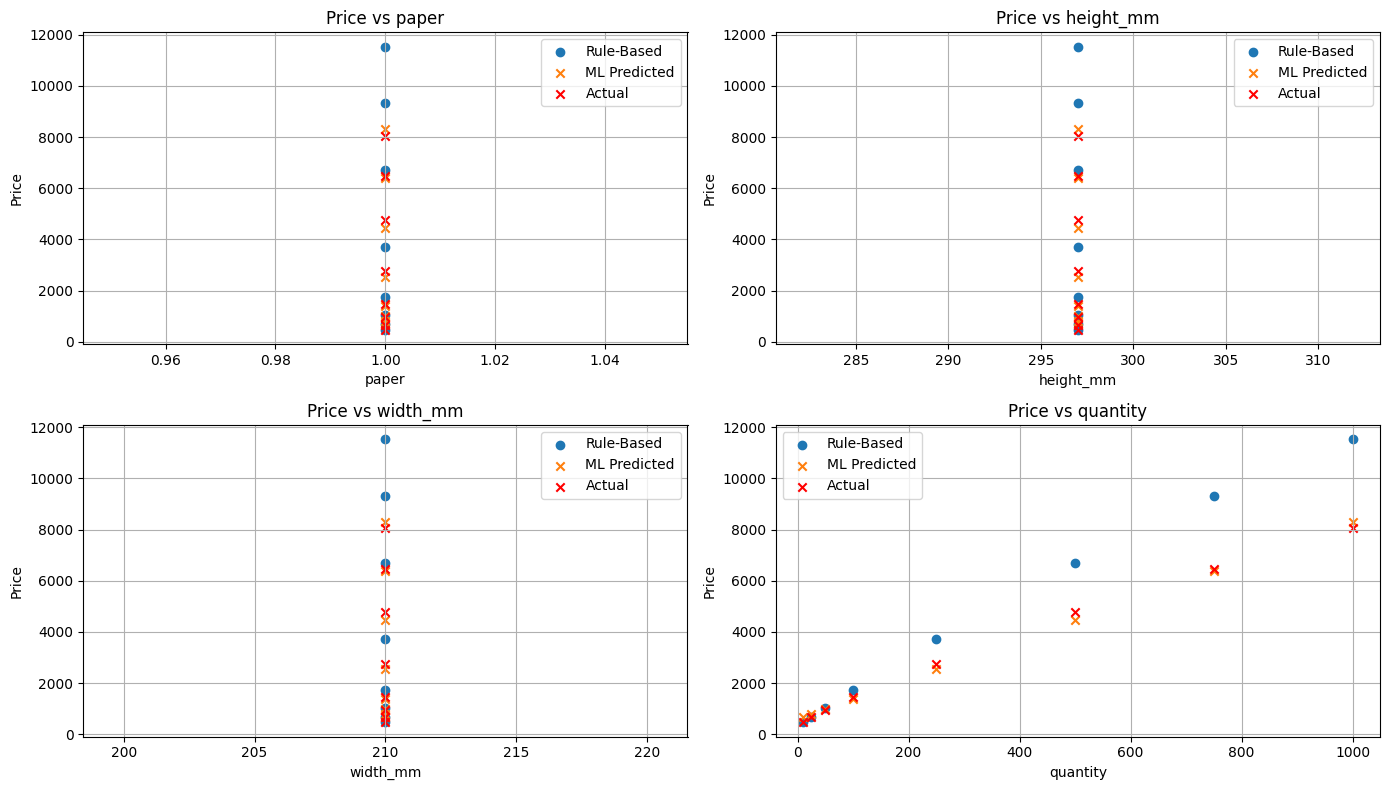

In [523]:
 
features = ['paper', 'height_mm', 'width_mm', 'quantity']

# Prepare ML predictions and Rule-based prices
ml_prices = model.predict(X_norm)
rule_based_prices = []

for idx, row in df.iterrows():
    request = PriceCalculationRequest(
        product_name="Premium Poster",
        quantity=int(row['quantity']),
        selected_attributes=[
            Attribute("paper", "matte"),
            Attribute("size", "A3")
        ],
        delivery_method="express"
    )
    price_data = pricing_engine.calculate_price(request)
    rule_based_prices.append(price_data['totalPrice'])

# Plot comparison for each feature
fig, axes = plt.subplots(2, 2, figsize=(14,8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], rule_based_prices, marker='o', label='Rule-Based')
    axes[i].scatter(df[feature], ml_prices, marker='x', label='ML Predicted')
    axes[i].scatter(df[feature], df['price'], marker='x',c='r', label='Actual')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price vs {feature}')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()